In [25]:
import os
import pandas as pd
import numpy as np
from datetime import datetime

In [26]:
df4 = pd.read_csv("C:\Datathon\GPTWarriors_FirstSubmission_Datathon2025\comments4.csv")
df4.shape

(999999, 10)

In [27]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   kind             999999 non-null  object 
 1   commentId        999999 non-null  int64  
 2   channelId        999999 non-null  int64  
 3   videoId          999999 non-null  int64  
 4   authorId         999999 non-null  int64  
 5   textOriginal     999937 non-null  object 
 6   parentCommentId  109338 non-null  float64
 7   likeCount        999999 non-null  int64  
 8   publishedAt      999999 non-null  object 
 9   updatedAt        999999 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 76.3+ MB


In [28]:
df4.head()

,kind,commentId,channelId,videoId,authorId,textOriginal,parentCommentId,likeCount,publishedAt,updatedAt
0,youtube#comment,1546147,1583,5446,2049014,So nature and amazing ❤,NaN,0,2023-09-06 21:14:57+00:00,2023-09-06 21:14:56+00:00
1,youtube#comment,70185,1658,91495,1676079,"@@xrose2030 so by definition, this commercial ...",913915.0,0,2021-07-02 02:54:27+00:00,2021-07-02 02:54:27+00:00
2,youtube#comment,1315458,22013,48712,164755,Blend blend,NaN,0,2025-01-03 12:16:32+00:00,2025-01-03 12:16:32+00:00
3,youtube#comment,2790969,41246,18969,2963595,East or west India is best,NaN,0,2022-05-31 06:39:58+00:00,2022-05-31 06:39:58+00:00
4,youtube#comment,3834158,41734,27096,2307720,I freaking feel like a student learning new th...,NaN,0,2024-03-31 05:29:58+00:00,2024-03-31 05:29:58+00:00


In [29]:
df4.dtypes

kind                object
commentId            int64
channelId            int64
videoId              int64
authorId             int64
textOriginal        object
parentCommentId    float64
likeCount            int64
publishedAt         object
updatedAt           object
dtype: object

In [30]:
trend = df4[["textOriginal", "likeCount", "publishedAt"]].copy()
trend

,textOriginal,likeCount,publishedAt
0,So nature and amazing ❤,0,2023-09-06 21:14:57+00:00
1,"@@xrose2030 so by definition, this commercial ...",0,2021-07-02 02:54:27+00:00
2,Blend blend,0,2025-01-03 12:16:32+00:00
3,East or west India is best,0,2022-05-31 06:39:58+00:00
4,I freaking feel like a student learning new th...,0,2024-03-31 05:29:58+00:00
...,...,...,...
999994,beneran mirip nyaiii airinnn😭❤️,22,2020-02-06 14:46:35+00:00
999995,THE MAGIC OF MAKEUP,1,2023-06-03 06:25:10+00:00
999996,Wow is so beautiful ❤️❤️❤️❤️🎉🎉,0,2024-08-12 23:54:38+00:00
999997,dead,0,2021-09-25 20:32:49+00:00


In [31]:
trend['likeCount'] = pd.to_numeric(trend['likeCount'], errors='coerce')
trend['publishedAt'] = pd.to_datetime(trend['publishedAt'], errors='coerce', utc=True)


In [32]:
trend.isnull().sum()

textOriginal    62
likeCount        0
publishedAt      0
dtype: int64

In [33]:
trend = trend.dropna(subset=["textOriginal", "publishedAt"]).reset_index(drop=True)
trend["likecount"] = trend["likeCount"].fillna(0).astype('int64')
trend

,textOriginal,likeCount,publishedAt,likecount
0,So nature and amazing ❤,0,2023-09-06 21:14:57+00:00,0
1,"@@xrose2030 so by definition, this commercial ...",0,2021-07-02 02:54:27+00:00,0
2,Blend blend,0,2025-01-03 12:16:32+00:00,0
3,East or west India is best,0,2022-05-31 06:39:58+00:00,0
4,I freaking feel like a student learning new th...,0,2024-03-31 05:29:58+00:00,0
...,...,...,...,...
999932,beneran mirip nyaiii airinnn😭❤️,22,2020-02-06 14:46:35+00:00,22
999933,THE MAGIC OF MAKEUP,1,2023-06-03 06:25:10+00:00,1
999934,Wow is so beautiful ❤️❤️❤️❤️🎉🎉,0,2024-08-12 23:54:38+00:00,0
999935,dead,0,2021-09-25 20:32:49+00:00,0


In [34]:
trend.describe(include='all')

,textOriginal,likeCount,publishedAt,likecount
count,999937,999937.000000,999937,999937.000000
unique,831993,NaN,NaN,NaN
top,❤,NaN,NaN,NaN
freq,4320,NaN,NaN,NaN
mean,NaN,10.397543,2023-09-15 06:22:53.713163520+00:00,10.397543
min,NaN,0.000000,2020-01-04 07:53:37+00:00,0.000000
25%,NaN,0.000000,2022-12-23 21:59:56+00:00,0.000000
50%,NaN,0.000000,2023-11-14 12:11:55+00:00,0.000000
75%,NaN,0.000000,2024-10-31 03:40:17+00:00,0.000000
max,NaN,194610.000000,2025-07-20 20:15:16+00:00,194610.000000


In [35]:
oldest = trend['publishedAt'].min()
newest = trend['publishedAt'].max()

In [36]:
oldest

Timestamp('2020-01-04 07:53:37+0000', tz='UTC')

In [37]:
newest

Timestamp('2025-07-20 20:15:16+0000', tz='UTC')

In [38]:
import matplotlib.pyplot as plt
%matplotlib inline

In [39]:
trend['quarter'] = trend['publishedAt'].dt.to_period('Q').astype(str)
trend

C:\Users\User\AppData\Local\Temp\ipykernel_29620\1723595286.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  trend['quarter'] = trend['publishedAt'].dt.to_period('Q').astype(str)


,textOriginal,likeCount,publishedAt,likecount,quarter
0,So nature and amazing ❤,0,2023-09-06 21:14:57+00:00,0,2023Q3
1,"@@xrose2030 so by definition, this commercial ...",0,2021-07-02 02:54:27+00:00,0,2021Q3
2,Blend blend,0,2025-01-03 12:16:32+00:00,0,2025Q1
3,East or west India is best,0,2022-05-31 06:39:58+00:00,0,2022Q2
4,I freaking feel like a student learning new th...,0,2024-03-31 05:29:58+00:00,0,2024Q1
...,...,...,...,...,...
999932,beneran mirip nyaiii airinnn😭❤️,22,2020-02-06 14:46:35+00:00,22,2020Q1
999933,THE MAGIC OF MAKEUP,1,2023-06-03 06:25:10+00:00,1,2023Q2
999934,Wow is so beautiful ❤️❤️❤️❤️🎉🎉,0,2024-08-12 23:54:38+00:00,0,2024Q3
999935,dead,0,2021-09-25 20:32:49+00:00,0,2021Q3


In [40]:
comment_counts = trend['quarter'].value_counts().sort_index()

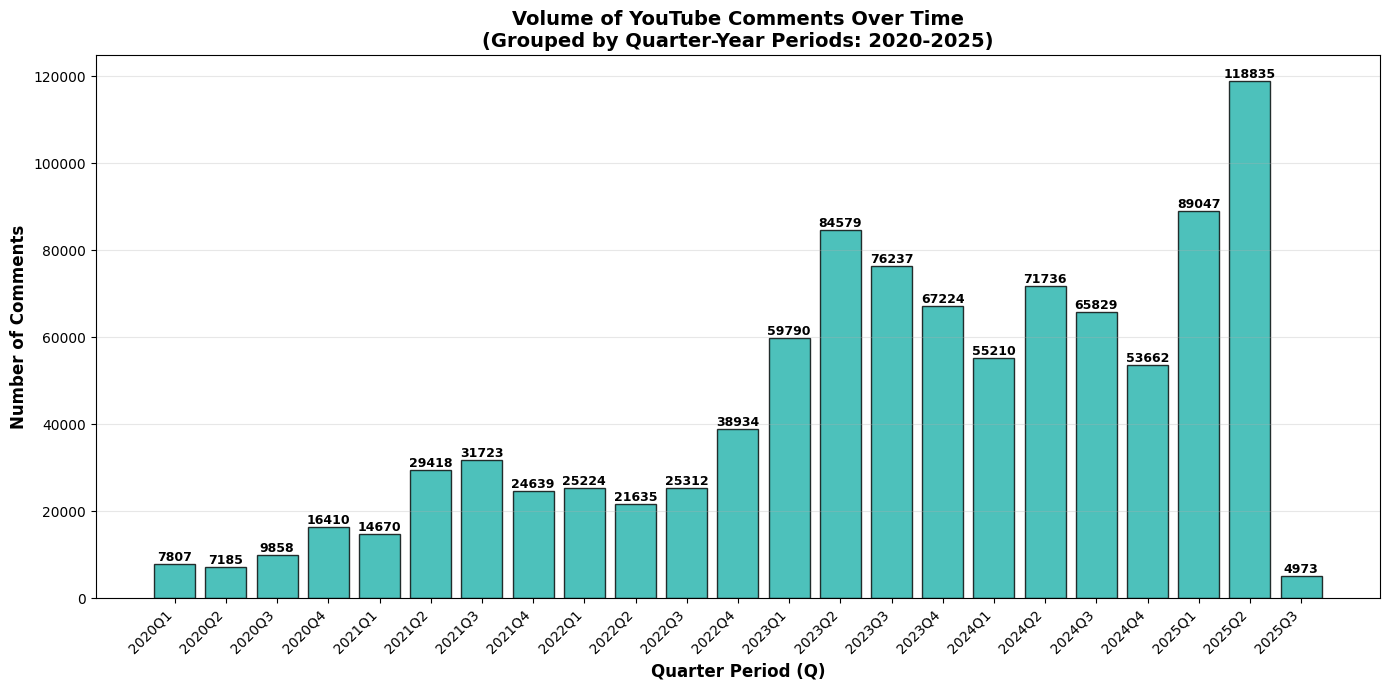

In [41]:
plt.figure(figsize=(14, 7))
bars = plt.bar(comment_counts.index.astype(str), comment_counts.values, 
               color='lightseagreen', edgecolor='black', alpha=0.8)

plt.xlabel('Quarter Period (Q)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Comments', fontsize=12, fontweight='bold')
plt.title('Volume of YouTube Comments Over Time\n(Grouped by Quarter-Year Periods: 2020-2025)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()